# Week 11: Clustering

**Goal:** Apply K-Means (k=8) to the audio features without using any labels.  Evaluate how well the clusters align with true emotions using ARI and NMI.  Visualize in 2D.

**Deliverable:** `minilearn/clustering.py` (KMeans complete) + this notebook.

---
## Checklist
- [ ] `KMeans` in MiniLearn — Lloyd's algorithm with n_init restarts
- [ ] Evaluate with Adjusted Rand Index (ARI) and Normalized Mutual Information (NMI)
- [ ] PCA 2D scatter: cluster assignment vs true emotion label
- [ ] t-SNE 2D scatter (optional but recommended)
- [ ] Optional: Hierarchical Clustering (sklearn), DBSCAN

In [1]:
import os
import sys
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sys.path.insert(0, os.path.abspath('..'))
warnings.filterwarnings('ignore')

from minilearn.clustering import KMeans
from minilearn.decomposition import PCA

from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score
from sklearn.cluster import AgglomerativeClustering
from sklearn.manifold import TSNE
from scipy.cluster.hierarchy import dendrogram, linkage

OUTPUT_DIR = 'C:\\Users\\Grana\\Documents\\GitHub\\Project_CSE432_MG\\Project_CSE432-532\\SER_Project\\output'

EMOTION_MAP = {
    1: 'neutral', 2: 'calm',    3: 'happy',    4: 'sad',
    5: 'angry',   6: 'fearful', 7: 'disgust',  8: 'surprised'
}
emotion_labels = [EMOTION_MAP[i] for i in sorted(EMOTION_MAP)]

sns.set_theme(style='whitegrid', palette='tab10')
plt.rcParams['figure.dpi'] = 110

# Load scaled features (fit on train in Week 5; use full dataset for clustering)
X_train = np.load(os.path.join(OUTPUT_DIR, 'X_train.npy'))
X_test  = np.load(os.path.join(OUTPUT_DIR, 'X_test.npy'))
y_train = np.load(os.path.join(OUTPUT_DIR, 'y_train.npy')).astype(int)
y_test  = np.load(os.path.join(OUTPUT_DIR, 'y_test.npy')).astype(int)

# Combine train + test for clustering (unsupervised — labels not used in fit)
X_all = np.vstack([X_train, X_test])
y_all = np.concatenate([y_train, y_test])

print(f'Full dataset : {X_all.shape}  labels: {np.unique(y_all)}')

Full dataset : (2452, 112)  labels: [1 2 3 4 5 6 7 8]


## 1. K-Means Clustering (k=8)

Inertia (sum of squared distances) : 192514.13
Cluster sizes : {np.int64(0): np.int64(453), np.int64(1): np.int64(305), np.int64(2): np.int64(253), np.int64(3): np.int64(372), np.int64(4): np.int64(356), np.int64(5): np.int64(272), np.int64(6): np.int64(261), np.int64(7): np.int64(180)}

Adjusted Rand Index (ARI) : 0.0589  (1.0 = perfect, 0.0 = random)
Normalized Mutual Info    : 0.1197  (1.0 = perfect, 0.0 = no info)

Contingency table (rows = clusters, cols = true emotions):
True Emotion  angry  calm  disgust  fearful  happy  neutral  sad  surprised
Cluster                                                                    
0                76    29       66       57     74       20   46         85
1                11    88        1       42     44       43   76          0
2               110    11        7       57     46        4   16          2
3               125     0       19      102     82        0   33         11
4                16    95        0       47     64       45   

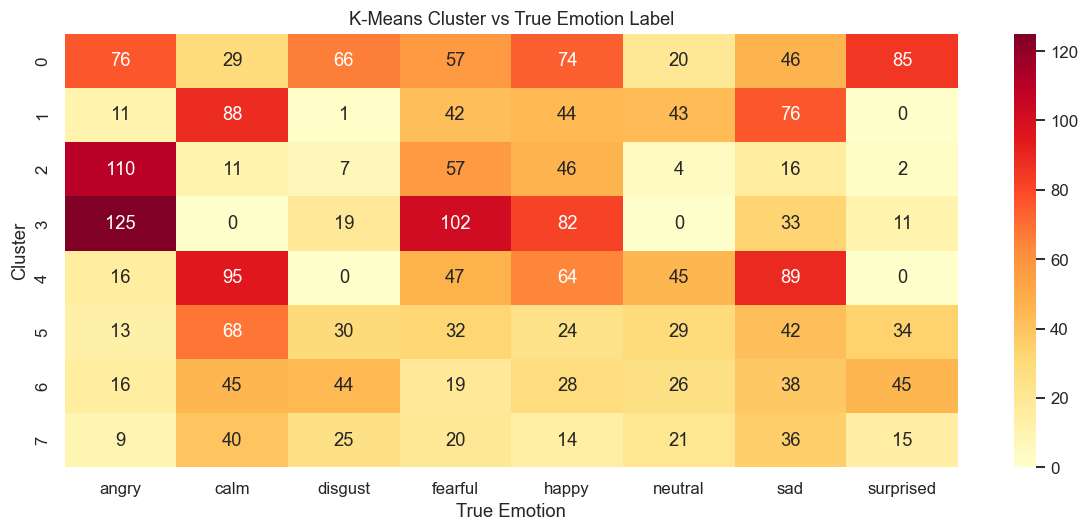

In [2]:
# Fit MiniLearn KMeans — labels NOT used during training
km = KMeans(k=8, max_iter=300, tol=1e-4, n_init=10, random_state=42)
km.fit(X_all)
cluster_labels = km.labels_

print(f'Inertia (sum of squared distances) : {km.inertia_:.2f}')
print(f'Cluster sizes : {dict(zip(*np.unique(cluster_labels, return_counts=True)))}')

# Evaluate against ground-truth emotion labels
ari = adjusted_rand_score(y_all, cluster_labels)
nmi = normalized_mutual_info_score(y_all, cluster_labels)

print(f'\nAdjusted Rand Index (ARI) : {ari:.4f}  (1.0 = perfect, 0.0 = random)')
print(f'Normalized Mutual Info    : {nmi:.4f}  (1.0 = perfect, 0.0 = no info)')

# ── Cluster-to-emotion contingency table ─────────────────────────────────────
contingency = pd.crosstab(
    pd.Series(cluster_labels, name='Cluster'),
    pd.Series([EMOTION_MAP[y] for y in y_all], name='True Emotion')
)
print('\nContingency table (rows = clusters, cols = true emotions):')
print(contingency.to_string())

fig, ax = plt.subplots(figsize=(11, 5))
sns.heatmap(contingency, annot=True, fmt='d', cmap='YlOrRd', ax=ax)
ax.set_title('K-Means Cluster vs True Emotion Label')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'kmeans_contingency.png'), bbox_inches='tight')
plt.show()

## 2. Elbow Method — Choosing k

k= 2  inertia=240590.73
k= 3  inertia=225868.53
k= 4  inertia=215369.38
k= 5  inertia=207637.62
k= 6  inertia=200822.90
k= 7  inertia=196197.97
k= 8  inertia=192645.03
k= 9  inertia=189517.40
k=10  inertia=186813.15
k=11  inertia=185351.64
k=12  inertia=182633.19
k=13  inertia=180685.90
k=14  inertia=178883.04
k=15  inertia=176705.96


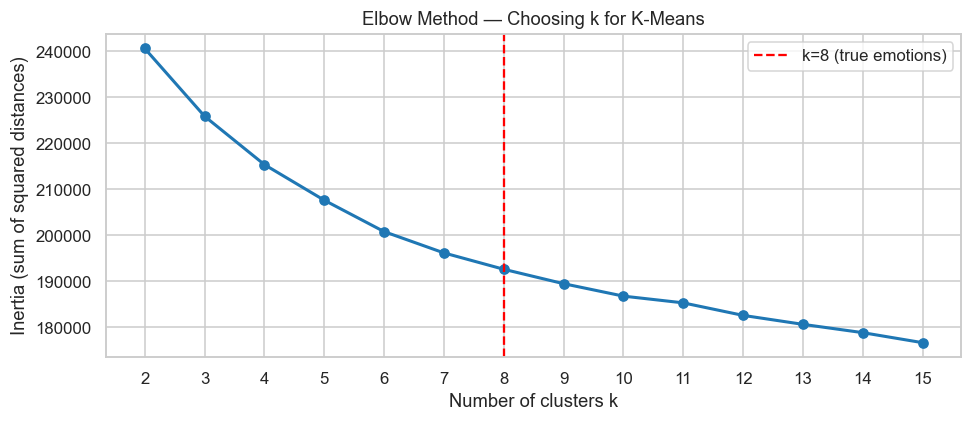

In [3]:
k_range  = range(2, 16)
inertias = []

for k in k_range:
    km_k = KMeans(k=k, max_iter=200, n_init=5, random_state=42)
    km_k.fit(X_all)
    inertias.append(km_k.inertia_)
    print(f'k={k:>2}  inertia={km_k.inertia_:.2f}')

# ── Elbow plot ────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(list(k_range), inertias, 'o-', linewidth=2)
ax.axvline(x=8, color='red', linestyle='--', linewidth=1.5, label='k=8 (true emotions)')
ax.set_xlabel('Number of clusters k')
ax.set_ylabel('Inertia (sum of squared distances)')
ax.set_title('Elbow Method — Choosing k for K-Means')
ax.set_xticks(list(k_range))
ax.legend()
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'kmeans_elbow.png'), bbox_inches='tight')
plt.show()

## 3. 2D Visualization

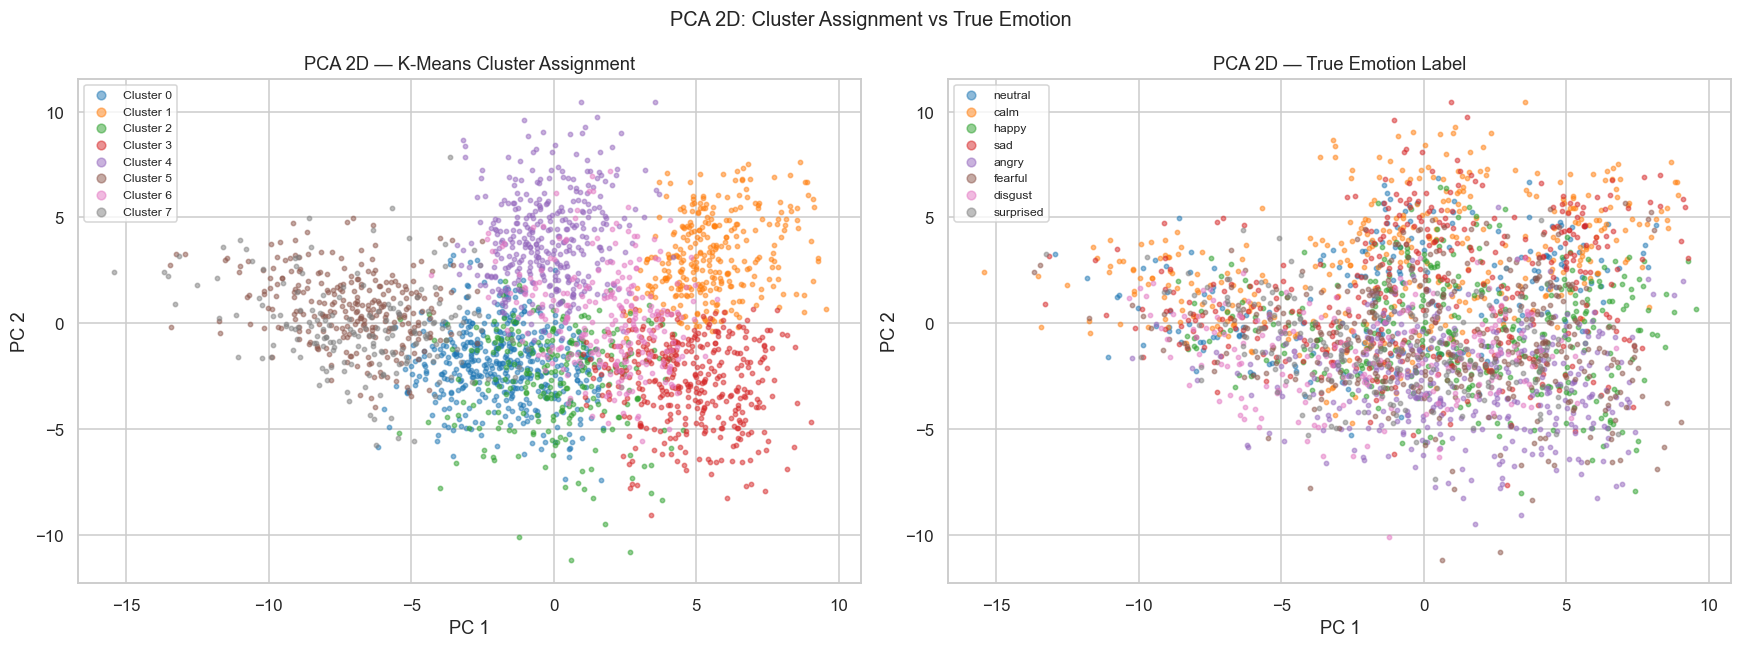

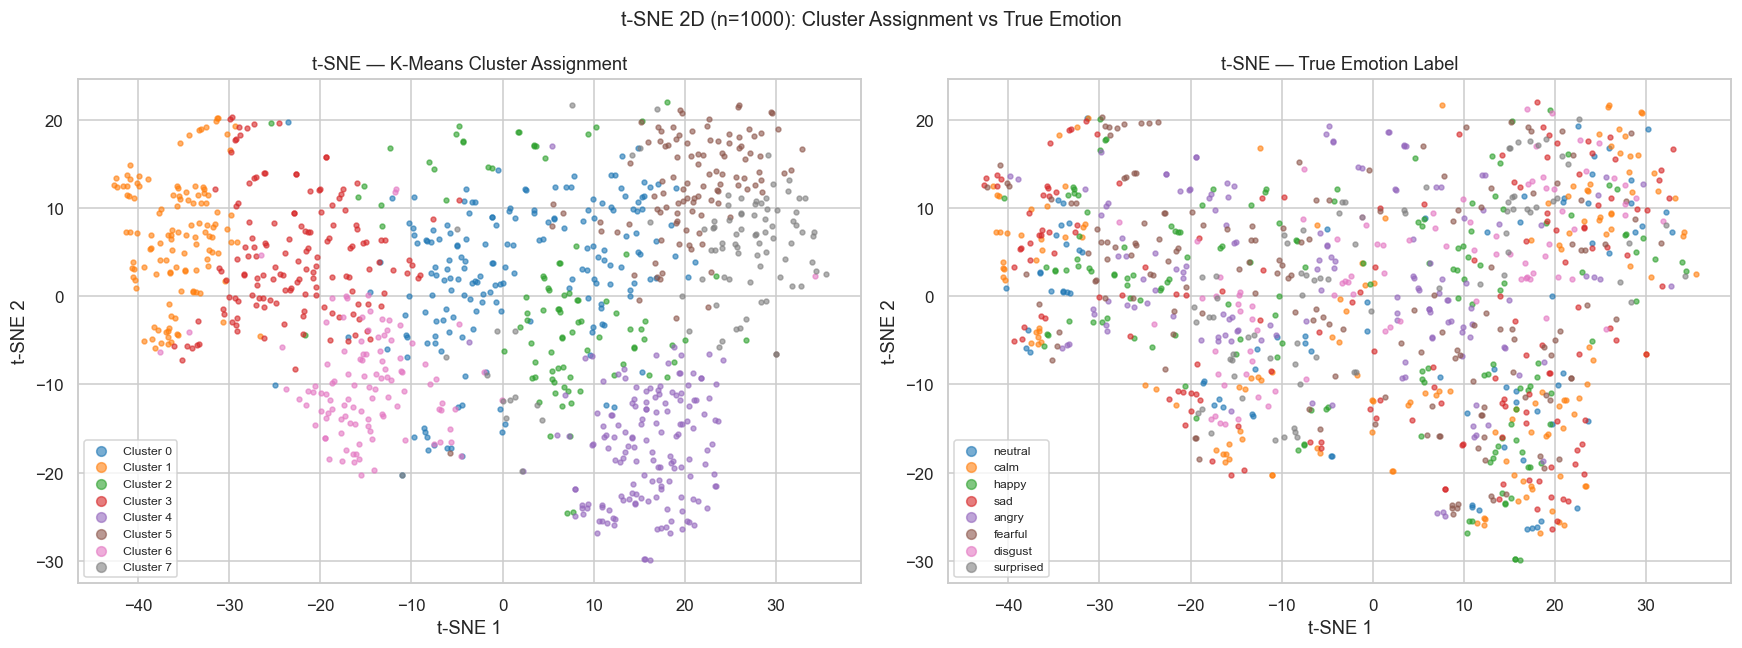

In [4]:
# ── PCA 2D projection ─────────────────────────────────────────────────────────
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_all)

palette   = sns.color_palette('tab10', 8)
cmap_clus = {i: palette[i] for i in range(8)}
cmap_emo  = {c: palette[i] for i, c in enumerate(sorted(EMOTION_MAP))}

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for c in range(8):
    mask = cluster_labels == c
    axes[0].scatter(X_pca[mask, 0], X_pca[mask, 1],
                    s=8, alpha=0.5, color=cmap_clus[c], label=f'Cluster {c}')
axes[0].set_title('PCA 2D — K-Means Cluster Assignment')
axes[0].set_xlabel('PC 1'); axes[0].set_ylabel('PC 2')
axes[0].legend(markerscale=2, fontsize=8, loc='best')

for emo_id in sorted(EMOTION_MAP):
    mask = y_all == emo_id
    axes[1].scatter(X_pca[mask, 0], X_pca[mask, 1],
                    s=8, alpha=0.5, color=cmap_emo[emo_id], label=EMOTION_MAP[emo_id])
axes[1].set_title('PCA 2D — True Emotion Label')
axes[1].set_xlabel('PC 1'); axes[1].set_ylabel('PC 2')
axes[1].legend(markerscale=2, fontsize=8, loc='best')

plt.suptitle('PCA 2D: Cluster Assignment vs True Emotion', fontsize=13)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'pca2d_clusters_vs_emotions.png'), bbox_inches='tight')
plt.show()

# ── t-SNE 2D projection (subsample 1000 points for speed) ────────────────────
n_tsne   = min(1000, len(X_all))
idx_sub  = np.random.default_rng(42).choice(len(X_all), n_tsne, replace=False)
X_sub    = X_all[idx_sub]
cl_sub   = cluster_labels[idx_sub]
y_sub    = y_all[idx_sub]

tsne   = TSNE(n_components=2, perplexity=40, random_state=42, max_iter=1000)
X_tsne = tsne.fit_transform(X_sub)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for c in range(8):
    mask = cl_sub == c
    axes[0].scatter(X_tsne[mask, 0], X_tsne[mask, 1],
                    s=10, alpha=0.6, color=cmap_clus[c], label=f'Cluster {c}')
axes[0].set_title('t-SNE — K-Means Cluster Assignment')
axes[0].set_xlabel('t-SNE 1'); axes[0].set_ylabel('t-SNE 2')
axes[0].legend(markerscale=2, fontsize=8)

for emo_id in sorted(EMOTION_MAP):
    mask = y_sub == emo_id
    axes[1].scatter(X_tsne[mask, 0], X_tsne[mask, 1],
                    s=10, alpha=0.6, color=cmap_emo[emo_id], label=EMOTION_MAP[emo_id])
axes[1].set_title('t-SNE — True Emotion Label')
axes[1].set_xlabel('t-SNE 1'); axes[1].set_ylabel('t-SNE 2')
axes[1].legend(markerscale=2, fontsize=8)

plt.suptitle(f't-SNE 2D (n={n_tsne}): Cluster Assignment vs True Emotion', fontsize=13)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'tsne_clusters_vs_emotions.png'), bbox_inches='tight')
plt.show()

## 4. Optional: Hierarchical Clustering

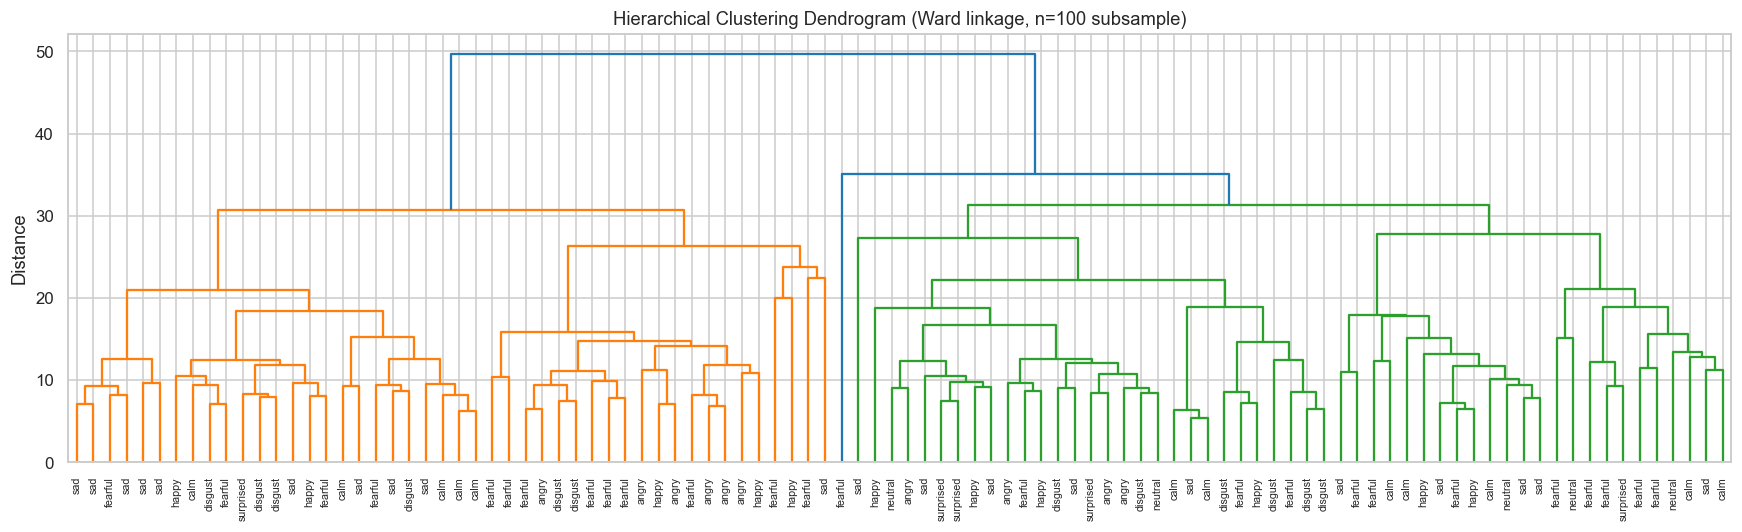

=== Hierarchical (Ward, k=8) ===
ARI : 0.0235
NMI : 0.0722

=== K-Means vs Hierarchical ===
Method                         ARI      NMI
-------------------------------------------
K-Means (minilearn)         0.0589   0.1197
Hierarchical (Ward)         0.0235   0.0722


In [5]:
from sklearn.cluster import AgglomerativeClustering
from scipy.cluster.hierarchy import dendrogram, linkage

# ── Dendrogram on a random subsample (full dataset is too large to visualise) ─
n_dendro = 100
idx_d    = np.random.default_rng(0).choice(len(X_all), n_dendro, replace=False)
X_dendro = X_all[idx_d]
y_dendro = y_all[idx_d]

Z = linkage(X_dendro, method='ward')

fig, ax = plt.subplots(figsize=(16, 5))
dendrogram(Z, ax=ax, color_threshold=0.7 * max(Z[:, 2]),
           labels=[EMOTION_MAP[y] for y in y_dendro],
           leaf_font_size=7, leaf_rotation=90)
ax.set_title(f'Hierarchical Clustering Dendrogram (Ward linkage, n={n_dendro} subsample)')
ax.set_ylabel('Distance')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'hierarchical_dendrogram.png'), bbox_inches='tight')
plt.show()

# ── Agglomerative Clustering (k=8) on full dataset ────────────────────────────
agg = AgglomerativeClustering(n_clusters=8, linkage='ward')
agg_labels = agg.fit_predict(X_all)

ari_agg = adjusted_rand_score(y_all, agg_labels)
nmi_agg = normalized_mutual_info_score(y_all, agg_labels)

print('=== Hierarchical (Ward, k=8) ===')
print(f'ARI : {ari_agg:.4f}')
print(f'NMI : {nmi_agg:.4f}')

print('\n=== K-Means vs Hierarchical ===')
print(f"{'Method':<25} {'ARI':>8} {'NMI':>8}")
print('-' * 43)
print(f"{'K-Means (minilearn)':<25} {ari:>8.4f} {nmi:>8.4f}")
print(f"{'Hierarchical (Ward)':<25} {ari_agg:>8.4f} {nmi_agg:>8.4f}")

## 5. Discussion

*Address:*
- *Do clusters correspond to emotions?  Which emotions cluster together naturally?*
- *What do the ARI and NMI scores tell you about the quality of the clustering?*
- *Why might K-Means struggle with emotion data?  (Think about cluster shapes and feature space.)*